In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
from src.data_format import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE, DATA_IN_JSONS, DATA_LABELLED
from src.accuracy import *
from src.utils import *
from src.impact_def import IMPACT_SUBTYPES_MERGED
from src.utils import MODEL_NAMES_MAP


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Coverage with accuracy

In [2]:
# load data extracted for a specific model


keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
res_savename_ext = "post_processed_test_reports_gaps_chunksize1000_meta-llama_llama-4-scout-17b-16e-instruct_v070426_v070426_geo"
# "post_processed_test_reports_gaps_chunksize1000_llama-3.3-70b-versatile_v060426_v060426_geo"
# "post_processed_labelled_reports_gaps_llama-3.3-70b-versatile_v270326_v270326_geo"  # merged_subtypes_

# load data (labelled)
res_savename_lab = "post_processed_labelled_reports_impacts_gaps_v050426_v070426_geo"

split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix2 = suffix + "_v271025"
suffix3 = suffix + "_v171025"
# load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+".gpkg"))
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+".gpkg"))
# load corresponding matched data
filename_match = f"matched_data_ws7qt-ws5ql-geo-valuepre-loose-nans_{res_savename_ext}"
# f"matched_data_ws2-geo-valuepre-strict-nans_{res_savename_ext}"
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_match + ".feather"))

DEF_CRS_EPSG = "EPSG:4326"
drop_appeals = [
    "MDRCO023",
    "MDRGW003",
    "MDRHU005",
    "MDRPH021",
    "MDRRS015",
    "MDRMN017",
    "MDRGT009",
    "MDRPG008",
    "MDREC019",
    "MDRTN010",
    "MDRCR012",
    "MDRGE019",]
keep_appeals = [appeal for appeal in extracted_df["appealCode"].unique() if appeal not in drop_appeals]
for name in ["matched_df", "extracted_df", "labelled_df"]:
    df = locals()[name]
    if "quanti" not in df.columns:
        df["quanti"] = df["impactValue"].notnull()
        df.loc[df["quanti"],"quanti"] = "quanti"
        df.loc[df["quanti"]==False,"quanti"] = "quali"
    df = df.set_crs(DEF_CRS_EPSG, allow_override=True)
    df = df[df["appealCode"].isin(keep_appeals)]
    locals()[name] = df  # assign back

# compute metrics
matched_df["impactValue_error"] = matched_df["impactValue_error"].replace([np.inf], np.nan)
matched_df["impactValue_sim"] = matched_df.apply(lambda x: 1-max_value_diff(x["impactValue"], x["impactValue_matched"]).clip(0,1), axis=1)

In [3]:
labelled_df.impactSubtype.value_counts()

impactSubtype
Affected People                                100
Residential Buildings                           88
Agriculture and Access to Food                  42
Displaced People                                32
Water, Sanitation, and Hygiene                  31
Transportation                                  25
Infected and Ill People                         24
Economy and Livelihood                          23
Human Deaths                                    23
Undefined Infrastructure and Service Access     21
Healthcare                                      14
Injured People                                  13
Human Health and Wellbeing                      10
Informal Settlements                             9
Education                                        9
Homeless People                                  9
Missing People                                   5
Power and Energy Production                      3
Recreation, Tourism, and Culture                 1
IT and Communicat

In [4]:
extracted_df.impactSubtype.value_counts()

impactSubtype
Affected People                                145
Water, Sanitation, and Hygiene                 118
Residential Buildings                          115
Agriculture and Access to Food                 110
Economy and Livelihood                          77
Human Health and Wellbeing                      73
Healthcare                                      70
Transportation                                  69
Displaced People                                66
Homeless People                                 48
Infected and Ill People                         41
DREF Allocation & Funding requirements          34
Targeted People                                 31
Education                                       28
Assisted People                                 28
Human Deaths                                    26
Unknown                                         24
Injured People                                  15
Informal Settlements                            11
Power and Energy 

In [5]:
## add other variables useful for analysis
# report length
extracted_df["reportSize"] = extracted_df["nathaz_text"].apply(len)

# report type
file_path = (
    DATA_IN_JSONS
    / "preproc_text_sel_gaps_all_ifrc_reports_info_unnested_with_text_v181125_v050326.csv"
)  #'all_ifrc_reports_info_processed_extended_format_nb_std_units.json' "nathaz_ifrc_reports_info_processed.json"
ifrc_reports_df = pd.read_csv(file_path)

keys = labelled_df[['appealCode', 'reportDate']].drop_duplicates()
labelled_reports_raw = ifrc_reports_df.merge(keys, on=['appealCode', 'reportDate'], how='inner')


# add vars to dfs
#extracted_df = extracted_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
#labelled_df = labelled_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
#matched_df = matched_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])

In [6]:
from src.labelling_helpers import filter_reports
ifrc_reports_df_filtered = filter_reports(ifrc_reports_df, take_latest=True)


/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:76: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: sort_appeal_type(x))
/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values(date_field, ascending=False).head(1))


In [7]:
from src.sanity_checks import flag_remove_cat
remove_cats = [
    "Unknown",
    "DREF Allocation & Funding requirements",
    "Targeted People",
    "Assisted People",
    "Other Human Impacts",
    "Other Infrastructural Impacts",
    "Other Agricultural Impacts",
    "Other Service Access Impacts",
]  # "Human Health and Wellbeing", "Economy and Livelihood"
extracted_df["flag_remove_cat"] = extracted_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
labelled_df["flag_remove_cat"] = labelled_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
matched_df["flag_remove_cat"] = matched_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)

In [8]:
#define threshold above which we consider a match

value_error_th = 0.1
sim_th = 0.5
filter_flags = ["flag_remove_cat", "flag_unit_nonstd", "flag_percent", "flag_remove_unit", "flag_value_no_unit"]#["flag_unit_nonstd"
keep_vars = []#["appealType", "reportSize", "reportDate"]
extracted_df_filter = filter_by_flags(extracted_df, flag_filters=filter_flags)
labelled_df_filter = filter_by_flags(labelled_df, flag_filters=filter_flags)
matched_df_filter1 = filter_by_flags(matched_df, flag_filters=filter_flags)
matched_df_filter2 = filter_matches(matched_df_filter1, value_error_th=value_error_th, sim_th=sim_th)
missed_df = labelled_df_filter[~labelled_df_filter.index.isin(matched_df_filter2["lab_match_id_sim"])]
false_positives_df = extracted_df_filter[~extracted_df_filter.index.isin(matched_df_filter2["ext_match_id_sim"])]
coverage_df_match = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key=None)
coverage_df_match_appeal = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="appealCode", keep_vars=keep_vars).reset_index(drop=False, names=["appealCode"])
coverage_df_match_subtype = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES_MERGED).reset_index(drop=False, names=["impactSubtype"])

In [9]:
missed_df.appealCode.value_counts()

appealCode
MDRUG050    27
MDRSD034    19
MDRYE011    16
MDRPK026    13
MDRBJ019    12
MDRKE058    10
MDRBD022     7
MDRS2001     6
MDRNG041     6
MDRDZ011     4
MDRRW022     4
MDRIQ014     2
MDRCM039     2
MDRMY003     1
MDRMZ024     1
Name: count, dtype: int64

In [10]:
missed_df.impactSubtype.value_counts()

impactSubtype
Affected People                                29
Residential Buildings                          27
Infected and Ill People                        15
Undefined Infrastructure and Service Access    12
Transportation                                  8
Agriculture and Access to Food                  8
Water, Sanitation, and Hygiene                  7
Human Deaths                                    5
Displaced People                                4
Economy and Livelihood                          4
Education                                       3
Human Health and Wellbeing                      2
Injured People                                  2
Informal Settlements                            1
Homeless People                                 1
Power and Energy Production                     1
Healthcare                                      1
Name: count, dtype: int64

In [11]:
false_positives_df.appealCode.value_counts()

appealCode
MDRKE058    46
MDRSD034    38
MDRUG050    33
MDRCM039    24
MDRRW022    22
MDRNG041    21
MDRZM022    16
MDRBD022    16
MDRDZ011    15
MDRBJ019    15
MDRIQ014    14
MDRPK026    13
MDRYE011    11
MDRSV012     8
MDRMZ024     7
MDRS2001     5
MDRCN006     2
MDRMY003     2
Name: count, dtype: int64

In [12]:
false_positives_df.impactSubtype.value_counts()

impactSubtype
Residential Buildings             33
Affected People                   33
Homeless People                   32
Economy and Livelihood            30
Displaced People                  29
Healthcare                        22
Agriculture and Access to Food    22
Human Health and Wellbeing        21
Infected and Ill People           19
Water, Sanitation, and Hygiene    16
Education                         15
Transportation                    13
Power and Energy Production        8
Informal Settlements               6
Injured People                     3
Human Deaths                       3
Missing People                     2
IT and Communication               1
Name: count, dtype: int64

In [35]:
print_match(matched_df[matched_df["impactSubtype"] == "Homeless People"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
8,MDRBD022,Homeless People,Affected People,102559.0,2176519.0,people,people,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.453125,['According to National disaster response coor...,"['of affected population 2,176,519 No.', 'Six ..."
9,MDRBD022,Homeless People,Displaced People,102559.0,31818.0,people,people,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.453125,['According to National disaster response coor...,"['of people who have moved to safe shelter 31,..."
14,MDRBD022,Homeless People,Undefined Infrastructure and Service Access,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.707107,0.422749,['Six days of heavy rain and onrush of upstrea...,['It is also reported that embankments have be...
42,MDRBJ019,Homeless People,Homeless People,3679.0,3679.0,people,people,"['Adoukandji', 'Ahodjinnako', 'Ahomadegbe', 'G...","['Mono', 'Couffo', 'Zou', 'Ouémé']",1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.928633,"['of which 3,679 people require priority emerg...",['DREF Operation Benin_Flood in Lalo Field vis...
44,MDRBJ019,Homeless People,Homeless People,3075.0,3679.0,people,people,"['Ahouada', 'Hazin', 'Yamontou', 'Ahomadegbe',...","['Mono', 'Couffo', 'Zou', 'Ouémé']",1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.879527,"['Of these households, 615 households have com...",['DREF Operation Benin_Flood in Lalo Field vis...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1162,MDRUG050,Homeless People,Education,NaN,NaN,null,null,"['Bweramule sub county', 'Butungama Sub-County...",['Bumwoni sub-county'],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.816497,0.466696,[],"['In Namisindwa, Bumwoni sub-county, a hailsto..."
1163,MDRUG050,Homeless People,Agriculture and Access to Food,NaN,NaN,null,null,"['Bweramule sub county', 'Butungama Sub-County...",['Bumwoni sub-county'],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.816497,0.466696,[],"['In Namisindwa, Bumwoni sub-county, a hailsto..."
1164,MDRUG050,Homeless People,Agriculture and Access to Food,NaN,NaN,null,null,"['Ntoroko District', 'Bweramule Sub-County', '...","['Eastern Uganda-Elgon', 'Mbale', 'Kapchorwa',...",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.549058,['Some of the affected persons are currently s...,['Appeal MDRUG050 Total DREF Allocation CHF 47...
1165,MDRUG050,Homeless People,Undefined Infrastructure and Service Access,NaN,NaN,null,null,"['Ntoroko District', 'Bweramule Sub-County', '...","['Eastern Uganda-Elgon', 'Mbale', 'Kapchorwa',...",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.549058,['Some of the affected persons are currently s...,['Appeal MDRUG050 Total DREF Allocation CHF 47...


In [14]:
labelled_df[
    (labelled_df["appealCode"] == "MDRUG050")
    & (labelled_df["impactSubtype"] == "Residential Buildings")
]  # & (labelled_df["impactSubtype"]=="Residential Buildings")

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry
181,2024-08-30,Residential Buildings,1129.0,homes,exact,NaN,NaN,['Appeal MDRUG050 Total DREF Allocation CHF 47...,['Uganda'],"['Ntoroko district', 'Budaka district', 'Buked...",...,9.0,"['Ntoroko', 'Budaka', 'Bukedea', 'Bulambuli', ...","['Western', 'Eastern', 'Northern', 'Central']",['UGA'],[165.0],"[1678.0, 1676.0, 1677.0, 1675.0]",[nan],NaN,False,"MULTIPOLYGON (((31.84153 2.36447, 31.84711 2.3..."
188,2024-08-30,Residential Buildings,1129.0,homes,exact,NaN,NaN,"['This represents - 11,775 people affected in ...",['Uganda'],"['Budaka district', 'Bukedea district', 'Bulam...",...,9.0,"['Ntoroko', 'Budaka', 'Bukedea', 'Bulambuli', ...","['Western', 'Eastern', 'Northern', 'Central']",['UGA'],[165.0],"[1678.0, 1676.0, 1677.0, 1675.0]",[nan],NaN,False,"MULTIPOLYGON (((31.84153 2.36447, 31.84711 2.3..."
198,2024-08-30,Residential Buildings,188.0,homes,exact,NaN,NaN,"['Reports from Joint Assessments, District Dis...",['Uganda'],['Nobongo Sub County'],...,0.0,['Uganda'],['Uganda'],['UGA'],[165.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((33.90371 -0.95, 31.86617 -1.02..."
199,2024-08-30,Residential Buildings,211.0,homes,exact,NaN,NaN,"['Reports from Joint Assessments, District Dis...",['Uganda'],['Nobongo Sub County'],...,0.0,['Uganda'],['Uganda'],['UGA'],[165.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((33.90371 -0.95, 31.86617 -1.02..."
207,2024-08-30,Residential Buildings,172.0,homes,exact,NaN,NaN,"[""On April 3rd, floods hit Bulambuli's Bunambu...",['Uganda'],['Bunambutye sub-county'],...,1.0,['Bunambutye'],['Bulambuli'],['UGA'],[165.0],[1676.0],[106278.0],NaN,False,"MULTIPOLYGON (((34.35487 1.56435, 34.3574 1.56..."
208,2024-08-30,Residential Buildings,154.0,homes,exact,NaN,NaN,"[""On April 3rd, floods hit Bulambuli's Bunambu...",['Uganda'],['Bunambutye sub-county'],...,1.0,['Bunambutye'],['Bulambuli'],['UGA'],[165.0],[1676.0],[106278.0],NaN,False,"MULTIPOLYGON (((34.35487 1.56435, 34.3574 1.56..."
214,2024-08-30,Residential Buildings,46.0,homes completly,exact,NaN,NaN,"['In Namisindwa, Bumwoni sub-county, a hailsto...",['Uganda'],['Bumwoni sub-county'],...,0.0,['Uganda'],['Uganda'],['UGA'],[165.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((33.90371 -0.95, 31.86617 -1.02..."
215,2024-08-30,Residential Buildings,104.0,homes,exact,NaN,NaN,"['In Namisindwa, Bumwoni sub-county, a hailsto...",['Uganda'],['Bumwoni sub-county'],...,0.0,['Uganda'],['Uganda'],['UGA'],[165.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((33.90371 -0.95, 31.86617 -1.02..."
221,2024-08-30,Residential Buildings,150.0,homes,exact,NaN,NaN,"['Similarly, a flood in Butaleja district, Buk...",['Uganda'],['Bukedi Sub County'],...,1.0,['Bukedi Road'],['Tororo'],['UGA'],[165.0],[1676.0],[106307.0],NaN,False,"MULTIPOLYGON (((34.18307 0.82924, 34.18204 0.8..."
222,2024-08-30,Residential Buildings,108.0,homes,exact,NaN,NaN,"['Similarly, a flood in Butaleja district, Buk...",['Uganda'],['Bukedi Sub County'],...,1.0,['Bukedi Road'],['Tororo'],['UGA'],[165.0],[1676.0],[106307.0],NaN,False,"MULTIPOLYGON (((34.18307 0.82924, 34.18204 0.8..."


In [15]:
extracted_df.loc[364]

impactSubtype                                        IT and Communication
impactValue                                                           NaN
impactValueMin                                                        NaN
impactValueMax                                                        NaN
impactValuePrecision                                                 None
                                              ...                        
gaul2_code              [100224.0, 101173.0, nan, 100556.0, 101371.0, ...
impactValueApprox                                                     NaN
flag_pop_cntry                                                      False
geometry                MULTIPOLYGON (((-1.3660676482032272 31.4471588...
reportSize                                                           7303
Name: 364, Length: 71, dtype: object

In [16]:
false_positives_df[false_positives_df["impactSubtype"] == "Affected People"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry,reportSize
207,Affected People,220000.0,NaN,NaN,exact,people,['Needs (Gaps) Identified Shelter Housing And ...,0,['Tokar'],['Continuous rainfall from June to September r...,...,['Tokar'],['Tawkar'],['SDN'],[161.0],[1637.0],[105843.0],NaN,False,"MULTIPOLYGON (((37.5206 18.73817, 37.52111 18....",30227
219,Affected People,NaN,NaN,NaN,None,null,['The impact of heavy rains and flash floods h...,0,"['Tokar', 'Port Sudan', 'Aqeeq', 'Red Sea Stat...",['The impact of heavy rains and flash floods h...,...,"['Kassala', 'White Nile', 'Northern State', 'C...","['Madeinat Kassala', 'Reifi Gharb Kassala', 'W...",['SDN'],[161.0],"[1632.0, 1644.0, 1636.0, 1629.0, 1642.0, 1630....","[105785.0, 105787.0, nan, 105843.0, 105840.0, ...",NaN,False,"MULTIPOLYGON (((36.42135 15.41089, 36.40845 15...",30227
292,Affected People,NaN,NaN,NaN,None,null,"['The lack of adequate housing, limited access...",0,"['Kassala', 'Gedaref', 'River Nile', 'White Ni...","['As of March 2025, needs remained dire in som...",...,"['Kassala', 'White Nile', 'Northern State', 'S...","['Madeinat Kassala', 'Reifi Gharb Kassala', 'W...",['SDN'],[161.0],"[1632.0, 1644.0, 1636.0, 1640.0, 1638.0, 1629....","[105785.0, 105787.0, nan]",NaN,False,"MULTIPOLYGON (((36.42135 15.41089, 36.40845 15...",30227
314,Affected People,3450000.0,NaN,NaN,approx,people,['This has led to high competition for limited...,1,"['Tete', 'Gaza', 'Manica', 'Inhambane']","['Provinces such as Tete, Gaza, Manica, and In...",...,"['Tete Province', 'Gaza Province', 'Manica Pro...","['Tete', 'Gaza', 'Manica', 'Inhambane']",['MOZ'],[148.0],"[1493.0, 1486.0, 1488.0, 1487.0]",[nan],NaN,False,"MULTIPOLYGON (((33.35115 -14.2194, 33.35708 -1...",3260
323,Affected People,NaN,NaN,NaN,None,null,"['According to the July 2024 IPC report, this ...",0,"['Tete', 'Gaza', 'Manica', 'Inhambane']","['Provinces such as Tete, Gaza, Manica, and In...",...,"['Tete Province', 'Gaza Province', 'Manica Pro...","['Tete', 'Gaza', 'Manica', 'Inhambane']",['MOZ'],[148.0],"[1493.0, 1486.0, 1488.0, 1487.0]",[nan],NaN,False,"MULTIPOLYGON (((33.35115 -14.2194, 33.35708 -1...",3260
345,Affected People,NaN,NaN,NaN,None,null,"['In Beni Abbes, rising water levels cut off m...",1,"['Beni Abbes', 'Bechar']","['In Beni Abbes, rising water levels cut off m...",...,"['Algeria', 'Bechar']","['Algeria', 'Bechar', ""Tizi N'Bechar""]",['DZA'],[101.0],"[nan, 1007.0, 1037.0]","[nan, 100224.0, 101173.0]",NaN,False,"MULTIPOLYGON (((-8.6844 27.39574, -8.66512 27....",7303
347,Affected People,NaN,NaN,NaN,None,null,['The flooding has devastated rural and nomadi...,0,"['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...","['The most affected areas include Béchar, Elba...",...,"['Bechar', 'Tamanrasset', 'Algeria', 'Tiaret',...","['Bechar', ""Tizi N'Bechar"", 'Tamanrasset', 'Al...",['DZA'],[101.0],"[1007.0, 1037.0, 1041.0, nan, 1043.0, 1044.0, ...","[100224.0, 101173.0, nan, 101371.0, 100981.0, ...",NaN,False,"MULTIPOLYGON (((-1.36607 31.44716, -1.60882 31...",7303
447,Affected People,NaN,NaN,NaN,None,null,"['People with disabilities, the elderly, pregn...",0,"['Couffo', 'Adoukandji', 'Ahodjinnako', 'Ahoma...","['The most affected districts are: Adoukandji,...",...,"['Kouffo Department', 'Benin', 'Ahomadégbé', '...","['Couffo', 'Benin', 'Bopa', 'Houéyogbé', 'Lalo...",['BEN'],[105.0],"[1076.0, nan, 1079.0, 1073.0, 1082.0]","[nan, 101763.0, 101766.0, 101755.0, 101730.0, ...",NaN,False,"MULTIPOLYGON (((1.70398 7.44491, 1.70626 7.443...",12554
493,Affected People,NaN,NaN,NaN,None,null,"['The scale of destruction is unprecedented, w...",0,"['Bauchi', 'Kebbi', 'Sokoto', 'Zamfara', 'Giad...",['The floods struck at the height of national ...,...,"['Bauchi', 'Kebbi State', 'Sokoto State', 'Zam...","['Bauchi', '

In [17]:
missed_df[(missed_df["impactSubtype"] == "Affected People") & (missed_df["appealCode"]=="MDRYE011")]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry
39,2022-08-03,Affected People,250.0,people,approx,NaN,NaN,"['In Saada Governorate,299 families were affec...",['Yemen'],"['Saada district', 'Sahara district', 'Majaz d...",...,1.0,"[""Sa'dah Governorate"", 'Shaharah District', 'A...","[""Sa'Dah"", 'Shaharah', 'Al Madan', 'Al Manar']",['YEM'],[282.0],"[3284.0, 3276.0, 3277.0]","[nan, 133755.0, 133739.0, 133759.0]",NaN,False,"MULTIPOLYGON (((43.4407 17.55464, 43.44542 17...."
40,2022-08-03,Affected People,371.0,people,exact,NaN,NaN,['Based on YRCS and shelter cluster flood trac...,['Yemen'],['Al-Mahra'],...,0.0,['Al Mahrah Governorate'],['Al Maharah'],['YEM'],[282.0],[3274.0],[nan],NaN,False,"MULTIPOLYGON (((52.74411 17.30254, 52.74368 17..."
41,2022-08-03,Affected People,504.0,people,exact,NaN,NaN,['Based on YRCS and shelter cluster flood trac...,['Yemen'],['Al-Mahwit'],...,0.0,['Al Mahwit Governorate'],['Al Mahwit'],['YEM'],[282.0],[3275.0],[nan],NaN,False,"MULTIPOLYGON (((43.80861 15.57415, 43.81291 15..."
42,2022-08-03,Affected People,1085.0,people,exact,NaN,NaN,['Based on YRCS and shelter cluster flood trac...,['Yemen'],['Hadramout'],...,0.0,['Hadramaut Governorate'],['Hadramawt'],['YEM'],[282.0],[3278.0],[nan],NaN,False,"MULTIPOLYGON (((50.99471 16.95188, 50.99089 16..."
44,2022-08-03,Affected People,1127.0,people,exact,NaN,NaN,['Based on YRCS and shelter cluster flood trac...,['Yemen'],['Dhamar'],...,0.0,['Dhamar Governorate'],['Dhamar'],['YEM'],[282.0],[3277.0],[nan],NaN,False,"MULTIPOLYGON (((44.70279 14.97771, 44.7058 14...."
45,2022-08-03,Affected People,1211.0,people,exact,NaN,NaN,['Based on YRCS and shelter cluster flood trac...,['Yemen'],['Al-Bayda'],...,1.0,"[""Al Bayda' Governorate""]",['Al Bayda'],['YEM'],[282.0],[3271.0],[nan],NaN,False,"MULTIPOLYGON (((45.02844 14.8163, 45.03121 14...."
46,2022-08-03,Affected People,1239.0,people,exact,NaN,NaN,['Based on YRCS and shelter cluster flood trac...,['Yemen'],['Saada'],...,1.0,"[""Sa'dah Governorate""]","[""Sa'Dah""]",['YEM'],[282.0],[3284.0],[nan],NaN,False,"MULTIPOLYGON (((43.4407 17.55464, 43.44542 17...."
47,2022-08-03,Affected People,1610.0,people,exact,NaN,NaN,['Based on YRCS and shelter cluster flood trac...,['Yemen'],['Ibb'],...,1.0,['Ibb Governorate'],['Ibb'],['YEM'],[282.0],[3280.0],[nan],NaN,False,"MULTIPOLYGON (((44.08076 14.38973, 44.08362 14..."
48,2022-08-03,Affected People,2828.0,people,exact,NaN,NaN,['Based on YRCS and shelter cluster flood trac...,['Yemen'],['Al- Hodeida'],...,0.0,['Hodeidah'],['Al Hali'],['YEM'],[282.0],[3272.0],[133686.0],NaN,False,"MULTIPOLYGON (((42.97402 14.85085, 42.97711 14..."
50,2022-08-03,Affected People,3087.0,people,exact,NaN,NaN,['Based on YRCS and shelter cluster flood trac...,['Yemen'],['Amran'],...,1.0,"[""'Amran Governorate""]",['Amran'],['YEM'],[282.0],[3276.0],[nan],NaN,False,"MULTIPOLYGON (((43.7831 16.68316, 43.78493 16...."


In [18]:
from src.data_format import listify_strings


hazs = labelled_df_filter.hazards.apply(listify_strings)
hazs.explode().nunique()

10

In [19]:

nboots = 5000
df_list = []
for qq in ["all", "quanti", "quali"]:
    if qq == "all":
        labelled_dfq = labelled_df_filter
        extracted_dfq = extracted_df_filter
        matched_df_filterq = matched_df_filter2
    else:
        labelled_dfq = labelled_df_filter[labelled_df_filter["quanti"]==qq]
        extracted_dfq = extracted_df_filter[extracted_df_filter["quanti"]==qq]
        matched_df_filterq = matched_df_filter2[matched_df_filter2["quanti"]==qq]
    n_ext = len(extracted_dfq)
    n_lab = len(labelled_dfq)
    tps = true_positives(matched_df_filterq)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
            "quanti" : qq,
            "n_ext": n_ext,
            "n_lab": n_lab,
            "tps": tps,
            "fps": fps,
            "fns": fns,
            "f1": f1s,
            "precision": precisions,
            "recall": recalls,
            "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
            "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
            "precision_low_err": precisions - bs_metric_dict["precision"][0],
            "precision_high_err": bs_metric_dict["precision"][1] - precisions,
            "recall_low_err": recalls - bs_metric_dict["recall"][0],
            "recall_high_err": bs_metric_dict["recall"][1] - recalls

    }
    df_list.append(pd.DataFrame(dict_res, index=[0]))

f1_bs_all = pd.concat(df_list)



In [20]:
f1_bs_all

,quanti,n_ext,n_lab,tps,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,all,996,469,339,657,130,0.462799,0.340361,0.722814,0.032137,0.031854,0.028678,0.029117,0.041099,0.040606
0,quanti,387,314,230,157,84,0.656205,0.594315,0.732484,0.041500,0.039085,0.048861,0.047243,0.049155,0.048766
0,quali,609,155,110,499,45,0.287958,0.180624,0.709677,0.041309,0.041544,0.029461,0.031105,0.073314,0.069464


In [21]:
group_keys = IMPACT_SUBTYPES_MERGED
group_key = "impactSubtype"
nboots = 5000
df_list = []
for group_id in group_keys:
    group_lab = labelled_df_filter[labelled_df_filter[group_key] == group_id]
    group_ext = extracted_df_filter[extracted_df_filter[group_key] == group_id]
    group_ext_match = matched_df_filter2[matched_df_filter2[group_key] == group_id]
    n_lab = len(group_lab)
    n_ext = len(group_ext)
    tps = true_positives(group_ext_match)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
        "tps": tps,
        "n_ext": n_ext,
        "n_lab": n_lab,
        "tps": tps,
        "fps": fps,
        "fns": fns,
        "f1": f1s,
        "precision": precisions,
        "recall": recalls,
        "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
        "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
        "precision_low_err": precisions - bs_metric_dict["precision"][0],
        "precision_high_err": bs_metric_dict["precision"][1] - precisions,
        "recall_low_err": recalls - bs_metric_dict["recall"][0],
        "recall_high_err": bs_metric_dict["recall"][1] - recalls,
    }
    df_list.append(pd.DataFrame(dict_res, index=[group_id]))
f1_bs_by_subtype = pd.concat(df_list).reset_index(drop=False, names=[group_key])

In [22]:
group_keys = labelled_df.appealCode.unique()
group_key = "appealCode"
nboots = 5000
df_list = []
for group_id in group_keys:
    group_lab = labelled_df_filter[labelled_df_filter[group_key] == group_id]
    group_ext = extracted_df_filter[extracted_df_filter[group_key] == group_id]
    group_ext_match = matched_df_filter2[matched_df_filter2[group_key] == group_id]
    n_lab = len(group_lab)
    n_ext = len(group_ext)
    tps = true_positives(group_ext_match)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
        "tps": tps,
        "n_ext": n_ext,
        "n_lab": n_lab,
        "tps": tps,
        "fps": fps,
        "fns": fns,
        "f1": f1s,
        "precision": precisions,
        "recall": recalls,
        "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
        "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
        "precision_low_err": precisions - bs_metric_dict["precision"][0],
        "precision_high_err": bs_metric_dict["precision"][1] - precisions,
        "recall_low_err": recalls - bs_metric_dict["recall"][0],
        "recall_high_err": bs_metric_dict["recall"][1] - recalls,
    }
    df_list.append(pd.DataFrame(dict_res, index=[group_id]))
f1_bs_by_appeal = pd.concat(df_list).reset_index(drop=False, names=[group_key])

In [23]:
# prepare data for plots
drop_appeals = []
f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
f1_bs_all["quanti"].replace("quali", "Qualitative total", inplace=True)
# f1_bs_all.set_index("quanti", drop=True, inplace=True)
# f1_bs_all.replace(np.nan, 0, inplace=True)
# f1_bs_by_key.replace(np.nan, 0, inplace=True)
f1_bs_by_appeal = f1_bs_by_appeal.loc[
    ~f1_bs_by_appeal["appealCode"].isin(drop_appeals)
]
f1_bs_by_appeal = f1_bs_by_appeal.sort_values(by="tps", ascending=False)

#add report length and type to f1_bs_by_appeal
#f1_bs_by_appeal = f1_bs_by_appeal.merge(extracted_df_filter[["appealCode", "reportSize", "appealType"]].drop_duplicates(), how="left", on="appealCode")


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_31834/872388171.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_31834/872388171.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we 

In [24]:
#prepare data for plots
relab_dict = {"Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene": "Water, Sanitation and Hygiene Infrastructure\nand Access to Water, Sanitation and Hygiene",
              "Power and Energy Production Infrastructure and Access to Power and Energy": "Power and Energy Production Infrastructure\nand Access to Power and Energy",
              "IT and Communication Infrastructure and Access to IT and Communication": "IT and Communication Infrastructure\nand Access to IT and Communication"}
f1_bs_by_subtype.loc[f1_bs_by_subtype["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"] = f1_bs_by_subtype.loc[coverage_df_match_subtype["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"].map(relab_dict)
drop_types = ["DREF Allocation", "Targeted People", "Assisted People"]
f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
f1_bs_all["quanti"].replace("quali", "Qualitative total", inplace=True)
#f1_bs_all.set_index("quanti", drop=True, inplace=True)
#f1_bs_all.replace(np.nan, 0, inplace=True)
#f1_bs_by_key.replace(np.nan, 0, inplace=True)
f1_bs_by_subtype = f1_bs_by_subtype.loc[~f1_bs_by_subtype["impactSubtype"].isin(drop_types)]
f1_bs_by_subtype = f1_bs_by_subtype.sort_values(by="tps", ascending=False)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_31834/886592431.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_31834/886592431.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we 

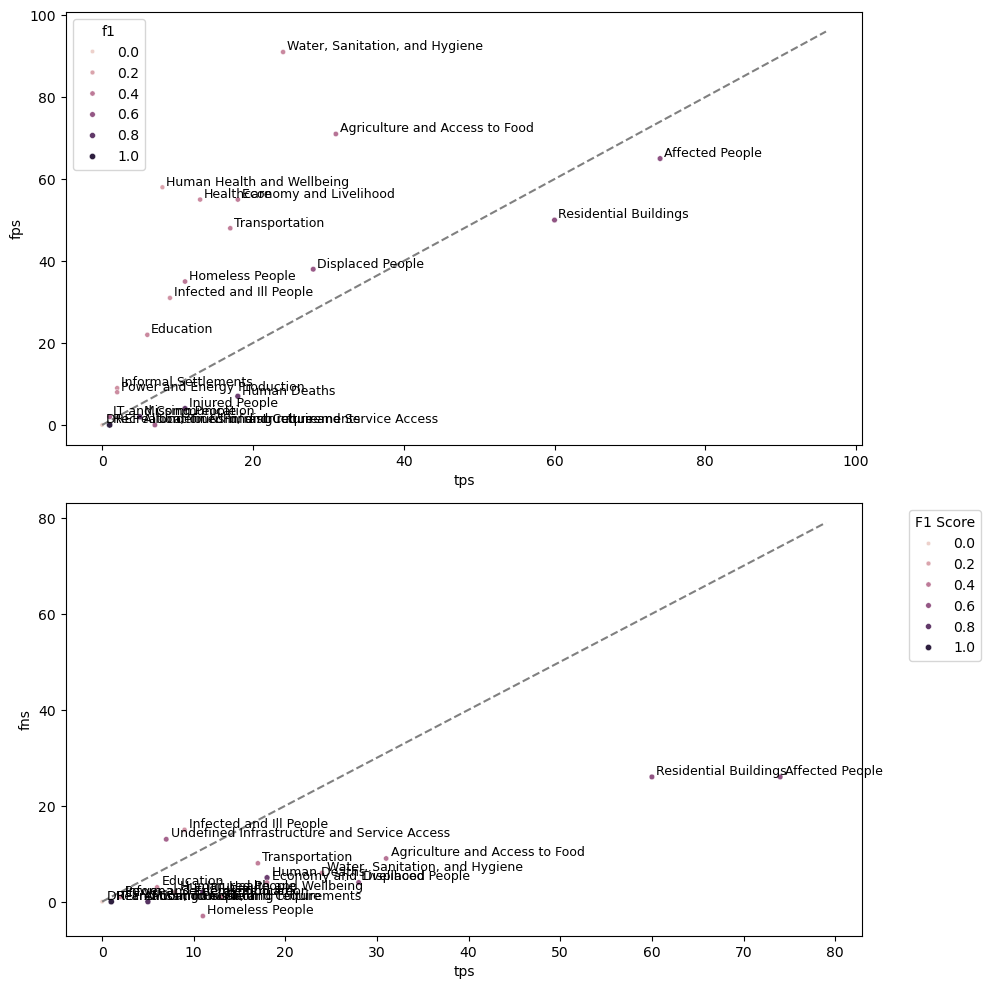

In [25]:
import seaborn as sns

fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(10,10))
xkey = "tps"
ykeys = ["fps", "fns"]
for i, ykey in enumerate(ykeys):
    ax = axes[i]

    sns.scatterplot(
        ax=ax,
        data=f1_bs_by_subtype,
        x=xkey,
        y=ykey,
        hue="f1",
        size="f1",
        sizes=(10, 20),
        legend=True,
    )
    # add impact subtype text
    for i, row in f1_bs_by_subtype.iterrows():
        ax.text(row[xkey]+0.5, row[ykey]+0.5, row["impactSubtype"], fontsize=9)

    # add 1-1 line
    max_val = max(f1_bs_by_subtype[xkey].max(), f1_bs_by_subtype[ykey].max()) + 5
    ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
    #ax.set_xlabel("Number of extracted impacts")
    #ax.set_ylabel("Number of labelled impacts")
    #ax.set_title("True Positives by Impact Subtype")
plt.legend(title="F1 Score", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [26]:
f1_bs_by_subtype

,impactSubtype,tps,n_ext,n_lab,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,Affected People,74,139,100,65,26,0.619247,0.532374,0.740000,0.072991,0.071229,0.083099,0.080765,0.090000,0.083546
8,Residential Buildings,60,110,86,50,26,0.612245,0.545455,0.697674,0.082515,0.073745,0.094487,0.090909,0.100117,0.095804
20,Agriculture and Access to Food,31,102,40,71,9,0.436620,0.303922,0.775000,0.105793,0.102854,0.084874,0.092351,0.133974,0.121552
2,Displaced People,28,66,32,38,4,0.571429,0.424242,0.875000,0.126984,0.107817,0.122655,0.121212,0.125000,0.096429
16,"Water, Sanitation, and Hygiene",24,115,30,91,6,0.331034,0.208696,0.800000,0.097458,0.097537,0.071944,0.074490,0.161111,0.135484
5,Human Deaths,18,25,23,7,5,0.750000,0.720000,0.782609,0.178571,0.117925,0.198261,0.168889,0.182609,0.169772
11,Economy and Livelihood,18,73,22,55,4,0.378947,0.246575,0.818182,0.128947,0.111249,0.093798,0.100647,0.173078,0.140152
15,Transportation,17,65,25,48,8,0.377778,0.261538,0.680000,0.136814,0.117068,0.100248,0.106109,0.197241,0.171852
17,Healthcare,13,68,14,55,1,0.317073,0.191176,0.928571,0.132863,0.132365,0.088235,0.098679,0.178571,0.071429
3,Homeless People,11,46,8,35,-3,0.407407,0.239130,1.375000,0.180992,0.123843,0.111471,0.130435,0.647727,-0.375000


In [27]:
f1_bs_by_appeal

,appealCode,tps,n_ext,n_lab,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
10,MDRUG050,67,164,94,97,27,0.519380,0.408537,0.712766,0.078564,0.071026,0.075252,0.075740,0.092766,0.091582
15,MDRSD034,66,205,85,139,19,0.455172,0.321951,0.776471,0.072501,0.066280,0.063598,0.062285,0.092260,0.085609
7,MDRKE058,23,83,33,60,10,0.396552,0.277108,0.696970,0.118774,0.103448,0.091923,0.100940,0.161315,0.151515
16,MDRRW022,21,67,25,46,4,0.456522,0.313433,0.840000,0.127110,0.123478,0.110534,0.113038,0.160000,0.121538
8,MDRNG041,18,57,24,39,6,0.444444,0.315789,0.750000,0.147147,0.123737,0.119075,0.122807,0.184783,0.163043
12,MDRPK026,18,54,31,36,13,0.423529,0.333333,0.580645,0.141478,0.119949,0.122807,0.129630,0.180645,0.176931
3,MDRS2001,16,24,22,8,6,0.695652,0.666667,0.727273,0.159067,0.127877,0.190476,0.179487,0.185606,0.177489
11,MDRDZ011,16,46,20,30,4,0.484848,0.347826,0.800000,0.151515,0.145289,0.135060,0.141063,0.188889,0.154545
0,MDRCN006,15,20,15,5,0,0.857143,0.750000,1.000000,0.169643,0.092857,0.200000,0.155672,0.200000,0.000000
13,MDRCM039,15,55,17,40,2,0.416667,0.272727,0.882353,0.143939,0.140295,0.112013,0.119447,0.168067,0.117647


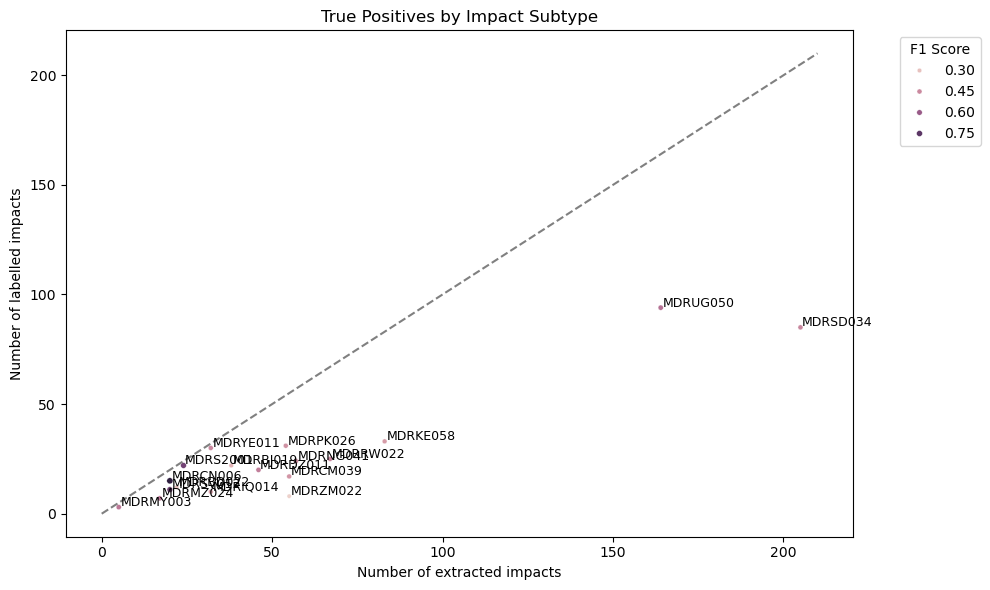

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x="n_ext",
    y="n_lab",
    hue="f1",
    size="f1",
    sizes=(10, 20),
    legend=True,
)

# add impact subtype text
for i, row in f1_bs_by_appeal.iterrows():
    ax.text(row["n_ext"] + 0.5, row["n_lab"] + 0.5, row["appealCode"], fontsize=9)

# add 1-1 line
max_val = max(f1_bs_by_appeal["n_ext"].max(), f1_bs_by_appeal["n_lab"].max()) + 5
ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
ax.set_xlabel("Number of extracted impacts")
ax.set_ylabel("Number of labelled impacts")
ax.set_title("True Positives by Impact Subtype")
plt.legend(title="F1 Score", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

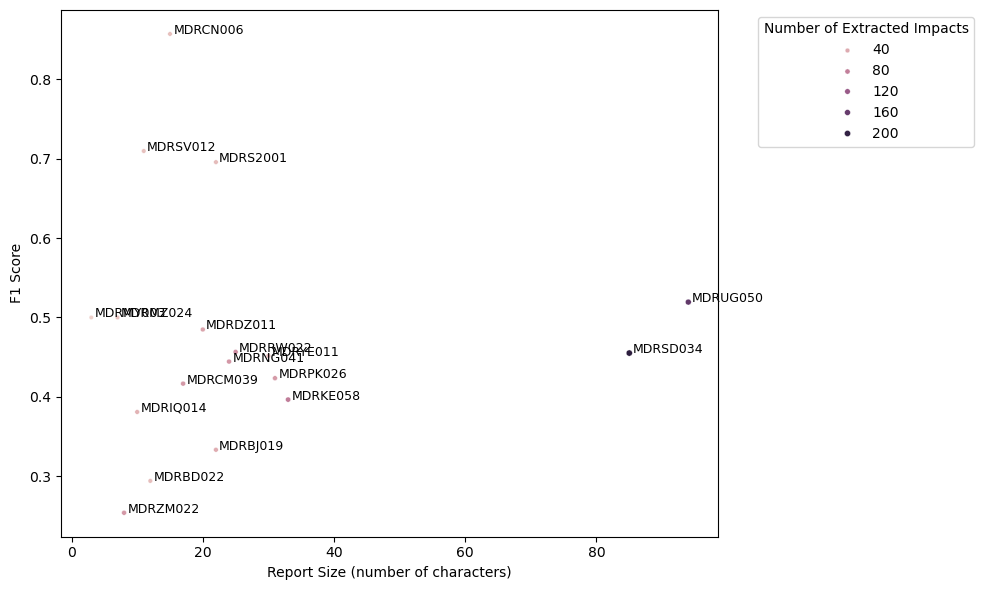

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey="n_lab"
ykey="f1"
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x=xkey,
    y=ykey,
    hue="n_ext",
    size="n_ext",
    sizes=(10, 20),
    legend=True,
)

# add impact subtype text
for i, row in f1_bs_by_appeal.iterrows():
    ax.text(row[xkey] + 0.5, row[ykey], row["appealCode"], fontsize=9)

# add 1-1 line
#max_val = max(f1_bs_by_appeal[xkey].max(), f1_bs_by_appeal[ykey].max()) + 5
#ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
ax.set_xlabel("Report Size (number of characters)")
ax.set_ylabel("F1 Score")
#ax.set_title("")
plt.legend(title="Number of Extracted Impacts", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

<Axes: xlabel='tps', ylabel='f1'>

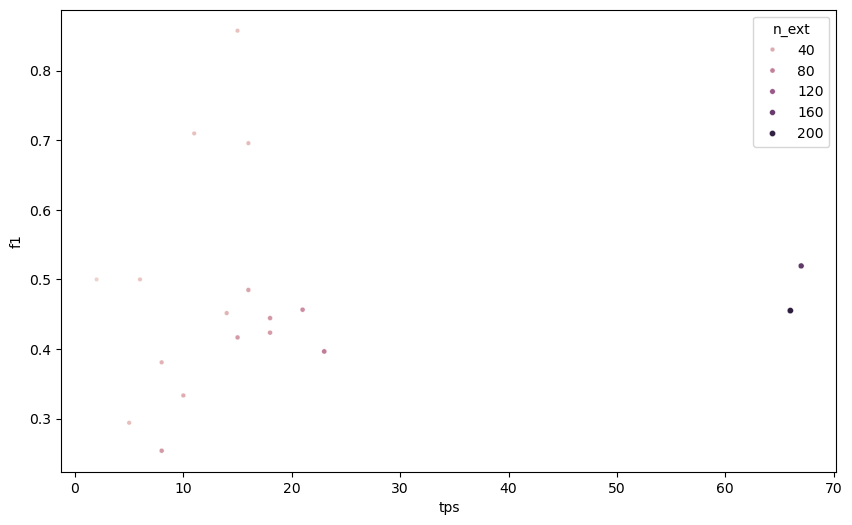

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey = "tps"
ykey = "f1"
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x=xkey,
    y=ykey,
    hue="n_ext",
    size="n_ext",
    sizes=(10, 20),
    legend=True,
)

In [43]:
labelled_df_filter.loc[125]

reportDate                                                     2024-04-26
impactSubtype                                            Displaced People
impactValue                                                       56375.0
impactUnit                                                         people
impactValuePrecision                                                exact
                                              ...                        
gaul1_code              [nan, 1353.0, 1354.0, 1362.0, 1367.0, 1369.0, ...
gaul2_code              [nan, 103528.0, 103534.0, 103579.0, 103622.0, ...
impactValueApprox                                                     NaN
flag_pop_cntry                                                      False
geometry                MULTIPOLYGON (((39.20222 -4.67677, 37.7669 -3....
Name: 125, Length: 61, dtype: object

In [37]:
labelled_df_filter[labelled_df_filter["impactSubtype"] == "Homeless People"]


,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry
152,2024-09-06,Homeless People,10000.0,people,approx,NaN,NaN,"['In Zamfara State, catastrophic floods left a...",['Nigeria'],"['Talata Mafara local government area', 'Ruwan...",...,3.0,"['Nigeria', 'Ruwan Gora', 'Morai', 'Makera', '...","['Nigeria', 'Bakura', 'Talata Mafara', 'Sandam...",['NGA'],[151.0],"[nan, 1553.0, 1537.0]","[nan, 105392.0, 105402.0, 105076.0]",NaN,False,"MULTIPOLYGON (((2.6917 6.25882, 2.74906 7.8707..."
190,2024-08-30,Homeless People,905.0,people,exact,NaN,NaN,"['Reports from Joint Assessments, District Dis...",['Uganda'],['Sironko district'],...,0.0,['Sironko'],"['Eastern', 'Western']",['UGA'],[165.0],"[1676.0, 1678.0]",[nan],NaN,False,"MULTIPOLYGON (((33.82564 2.35788, 33.84774 2.3..."
197,2024-08-30,Homeless People,190.0,people,exact,NaN,NaN,"['Reports from Joint Assessments, District Dis...",['Uganda'],['Nobongo Sub County'],...,0.0,['Uganda'],['Uganda'],['UGA'],[165.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((33.90371 -0.95, 31.86617 -1.02..."
228,2024-08-30,Homeless People,106.0,people,exact,NaN,NaN,"['Additionally, a landslide in Bududa district...",['Uganda'],['Buwali sub-county'],...,1.0,['Buwali'],['Namisindwa'],['UGA'],[165.0],[1676.0],[106300.0],NaN,False,"MULTIPOLYGON (((34.35848 0.9756, 34.35894 0.97..."
236,2024-08-30,Homeless People,109.0,homes,exact,NaN,NaN,"['In Mbale District, Bukasakya, and Bungokho, ...",['Uganda'],"['Bukasakya', 'Bungokho']",...,1.0,"['Uganda', 'Bungokho']","['Uganda', 'Bukedea']",['UGA'],[165.0],"[nan, 1676.0]","[nan, 106276.0]",NaN,False,"MULTIPOLYGON (((33.90371 -0.95, 31.86617 -1.02..."
240,2024-08-30,Homeless People,1530.0,people,exact,NaN,NaN,"['Moreover, floods struck Bookies sub-county, ...",['Uganda'],['Bookies sub-county'],...,0.0,['Uganda'],['Uganda'],['UGA'],[165.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((33.90371 -0.95, 31.86617 -1.02..."
254,2024-08-30,Homeless People,15400.0,people,exact,NaN,NaN,['Page 3 / 19 The flooding worsened on first h...,['Uganda'],[],...,0.0,['Uganda'],['Uganda'],['UGA'],[165.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((33.90371 -0.95, 31.86617 -1.02..."
347,2024-09-07,Homeless People,3679.0,people,exact,NaN,NaN,['DREF Operation Benin_Flood in Lalo Field vis...,['Benin'],"['Mono', 'Couffo', 'Zou', 'Ouémé']",...,2.0,"['Mono Department', 'Kouffo Department', 'Zou ...","['Mono', 'Couffo', 'Zou', 'Oueme']",['BEN'],[105.0],"[1079.0, 1076.0, 1082.0, 1080.0]",[nan],NaN,False,"MULTIPOLYGON (((1.92217 6.7823, 1.93023 6.7787..."


In [42]:
matched_df_filter2[matched_df_filter2["impactSubtype"] == "Homeless People"]["lab_match_id_sim"]

42      347.0
405     125.0
517     152.0
521     152.0
654     451.0
657     458.0
1035    190.0
1036    197.0
1053    228.0
1063    228.0
1068    240.0
1088    254.0
1091    240.0
1227     53.0
Name: lab_match_id_sim, dtype: float64

In [34]:
f1_bs_by_subtype

,impactSubtype,tps,n_ext,n_lab,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,Affected People,74,139,100,65,26,0.619247,0.532374,0.740000,0.072991,0.071229,0.083099,0.080765,0.090000,0.083546
8,Residential Buildings,60,110,86,50,26,0.612245,0.545455,0.697674,0.082515,0.073745,0.094487,0.090909,0.100117,0.095804
20,Agriculture and Access to Food,31,102,40,71,9,0.436620,0.303922,0.775000,0.105793,0.102854,0.084874,0.092351,0.133974,0.121552
2,Displaced People,28,66,32,38,4,0.571429,0.424242,0.875000,0.126984,0.107817,0.122655,0.121212,0.125000,0.096429
16,"Water, Sanitation, and Hygiene",24,115,30,91,6,0.331034,0.208696,0.800000,0.097458,0.097537,0.071944,0.074490,0.161111,0.135484
5,Human Deaths,18,25,23,7,5,0.750000,0.720000,0.782609,0.178571,0.117925,0.198261,0.168889,0.182609,0.169772
11,Economy and Livelihood,18,73,22,55,4,0.378947,0.246575,0.818182,0.128947,0.111249,0.093798,0.100647,0.173078,0.140152
15,Transportation,17,65,25,48,8,0.377778,0.261538,0.680000,0.136814,0.117068,0.100248,0.106109,0.197241,0.171852
17,Healthcare,13,68,14,55,1,0.317073,0.191176,0.928571,0.132863,0.132365,0.088235,0.098679,0.178571,0.071429
3,Homeless People,11,46,8,35,-3,0.407407,0.239130,1.375000,0.180992,0.123843,0.111471,0.130435,0.647727,-0.375000


ValueError: 'xerr' must not contain negative values

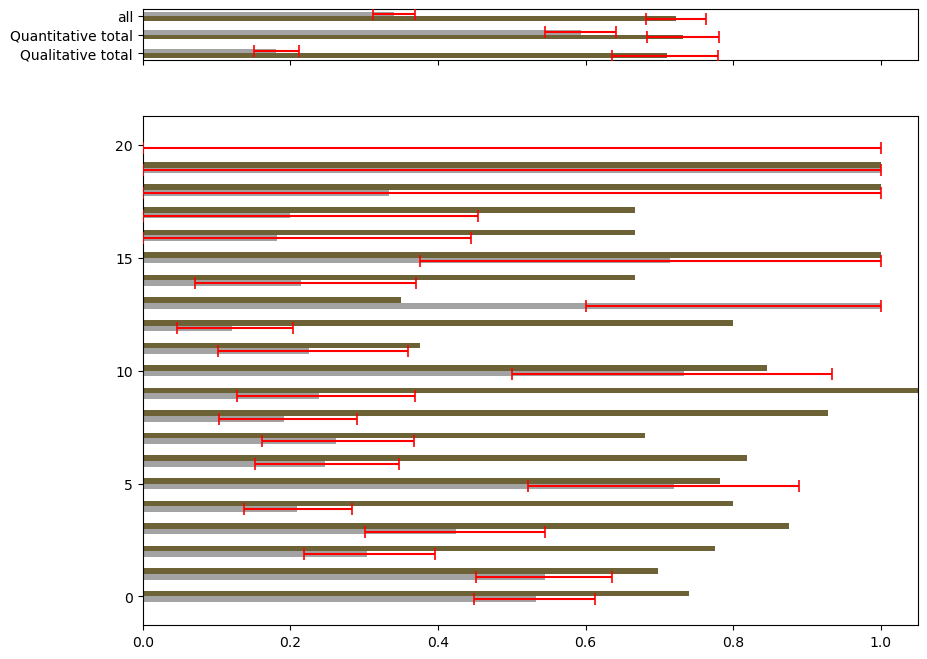

In [33]:
import textwrap
from click import group
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

metrics = ["precision", "recall"]#"f1"
colors = ["#a3a3a3", "#6c6236", "#5e0eff"]  # distinct colors for each metric
group_key = "impactSubtype"


fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharey=False, sharex=True, height_ratios=[1, 10])

# --- Function to plot grouped bars with error bars ---
def plot_metrics_with_errorbars(ax, df, x_col, metrics, colors):
    n_metrics = len(metrics)
    y_positions = np.arange(len(df))
    height = 0.25  # controls bar thickness
    spacing = 0.3  # space between metric groups

    for i, metric in enumerate(metrics):
        # compute shifted y positions for each metric
        offset = (i - (n_metrics - 1)/2) * height
        y_shifted = y_positions + offset

        val = df[f"{metric}"]
        lower = df[f"{metric}_low_err"]
        upper = df[f"{metric}_high_err"]

        ax.barh(
            y_shifted,
            val,
            height=height,
            color=colors[i],
            label=metric.capitalize()
        )

        # Add horizontal error bars
        xerr = [lower, upper]
        ax.errorbar(
            val, y_shifted, xerr=xerr,
            fmt='none', ecolor='red',
            elinewidth=1.5, capsize=4, capthick=1.2, zorder=5
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(df[x_col])
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)  # adjust if scores in [0,1]

# --- Plot bottom panel (all-level metrics) ---
plot_metrics_with_errorbars(ax[0], f1_bs_all, "quanti", metrics, colors)

# --- Plot top panel (by-key metrics) ---
plot_metrics_with_errorbars(ax[1], f1_bs_by_subtype, group_key, metrics, colors)

# --- Labels ---
ax[1].set_xlabel("Score")
ax[0].set_ylabel("")
ax[1].set_ylabel("")

# --- Create combined legend handles ---
err_proxy = Line2D([0], [0], color='red', lw=2, marker='_', markersize=10, label='95% CI')
bars_proxy = [Line2D([0], [0], color=c, lw=10, label=m.capitalize()) for m, c in zip(metrics, colors)]

# --- Add legend ---
#ax[1].get_legend().remove()
ax[0].legend(handles=bars_proxy + [err_proxy], loc=(0.82, -0.08), frameon=False)#title="Metrics"

ax[0].set_title("a)", fontweight="bold", loc="left")
ax[1].set_title("b)", fontweight="bold", loc="left")

## add grids
ax[0].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)
ax[1].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

plt.tight_layout()
plt.show()

fig.savefig(DATA_FIGURE / f"{'_'.join(metrics)}_vth-{value_error_th}_sth-{sim_th}_flt_{filename_match.replace(key, MODEL_NAMES_MAP[key])}.png", bbox_inches="tight", dpi=300)

In [ ]:
un_matched = matched_df_filter1[(matched_df_filter1["match_sim"] <= sim_th)]
un_matched_quali = un_matched[(matched_df_filter1["quanti"] == "quali")]
un_matched_quanti = un_matched[(matched_df_filter1["quanti"] == "quanti")]


/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)
/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


In [ ]:
un_matched_quali.impactSubtype.value_counts()

impactSubtype
Affected People                   28
Displaced People                  12
Infected and Ill People           12
Residential Buildings              8
Human Deaths                       5
Homeless People                    5
Human Health and Wellbeing         5
Injured People                     5
Economy and Livelihood             5
Power and Energy Production        4
Missing People                     2
Agriculture and Access to Food     1
Healthcare                         1
Name: count, dtype: int64

In [ ]:
un_matched_quanti.impactSubtype.value_counts()

impactSubtype
Residential Buildings             5
Water, Sanitation, and Hygiene    5
Informal Settlements              3
Agriculture and Access to Food    3
Education                         1
Healthcare                        1
Name: count, dtype: int64

In [ ]:
un_matched.impactSubtype.value_counts()

impactSubtype
Affected People                   28
Residential Buildings             13
Displaced People                  12
Infected and Ill People           12
Human Deaths                       5
Homeless People                    5
Human Health and Wellbeing         5
Injured People                     5
Water, Sanitation, and Hygiene     5
Economy and Livelihood             5
Agriculture and Access to Food     4
Power and Energy Production        4
Informal Settlements               3
Healthcare                         2
Missing People                     2
Education                          1
Name: count, dtype: int64

In [ ]:
un_matched.appealCode.value_counts()

appealCode
MDRRW022    32
MDRZM022    31
MDRUG050    24
MDRSD034    13
MDRYE011    11
Name: count, dtype: int64

In [ ]:
labelled_df_filter[labelled_df_filter["appealCode"] == "MDRZM022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry
170,2024-04-02,Affected People,5000000.0,people,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
171,2024-04-02,Agriculture and Access to Food,10000.0,km**2 of crop production and forestry,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
172,2024-04-02,Agriculture and Access to Food,NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
173,2024-04-02,"Water, Sanitation, and Hygiene",NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
174,2024-04-02,Economy and Livelihood,NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
175,2024-04-02,Agriculture and Access to Food,2040000.0,people,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
176,2024-04-02,Affected People,546139.0,people,exact,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['Kalabo district', 'Senanga district', 'Sikon...",...,0.0,"['Kalabo', 'Senanga', 'Sikongo', 'Shangombo', ...","['Kalabo', 'Senanga', 'Sikongo', 'Shangombo', ...",['ZMB'],[168.0],"[1720.0, 1717.0]","[106631.0, 106642.0, 106645.0, 106644.0, 10664...",NaN,False,"MULTIPOLYGON (((22.04535 -14.02934, 22.0482 -1..."
177,2024-04-02,Human Health and Wellbeing,NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."


In [ ]:
extracted_df_filter[extracted_df_filter["appealCode"] == "MDRZM022"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,flag_pop_cntry,geometry,reportSize
405,Affected People,5000000.0,NaN,NaN,exact,people,"['People Affected: 5,000,000 people']",0,"['Southern', 'North-Western', 'Western', 'Cent...",['The whole Southern half of Zambia is experie...,...,0,"['Southern Province', 'North-Western Province'...","['Northern', 'Southern', 'North-Western', 'Eas...",['ZMB'],[168.0],"[1718.0, 1719.0, 1717.0, 1713.0, 1720.0, 1711....","[nan, 106584.0, 106624.0, 106625.0, 106631.0, ...",False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555
408,Agriculture and Access to Food,NaN,NaN,NaN,None,null,['Staff checking on a maize field affected by ...,0,"['Mazabuka District', 'Southern Province', 'No...",['Staff checking on a maize field affected by ...,...,0,"['North-Western Province', 'Western Province',...","['North-Western', 'Eastern', 'Western', 'Centr...",['ZMB'],[168.0],"[1717.0, 1713.0, 1720.0, 1711.0, 1719.0, 1718....","[nan, 106624.0, 106584.0]",False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -...",14555
409,Economy and Livelihood,NaN,NaN,NaN,None,null,"['The Zambian president declared a drought, di...",0,"['Southern', 'North-Western', 'Western', 'Cent...",['The whole Southern half of Zambia is experie...,...,0,"['Southern Province', 'North-Western Province'...","['Northern', 'Southern', 'North-Western', 'Eas...",['ZMB'],[168.0],"[1718.0, 1719.0, 1717.0, 1713.0, 1720.0, 1711....","[nan, 106584.0, 106624.0, 106625.0, 106631.0, ...",False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555
410,Affected People,5000000.0,NaN,NaN,exact,people,"['1 million households have been affected, and...",0,"['Southern', 'North-Western', 'Western', 'Cent...",['The whole Southern half of Zambia is experie...,...,0,"['Southern Province', 'North-Western Province'...","['Northern', 'Southern', 'North-Western', 'Eas...",['ZMB'],[168.0],"[1718.0, 1719.0, 1717.0, 1713.0, 1720.0, 1711....","[nan, 106584.0, 106631.0, 106642.0, 106645.0, ...",False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555
411,Agriculture and Access to Food,10000.0,NaN,NaN,exact,km**2 of crop production and forestry,"['1 million households have been affected, and...",0,"['Southern', 'Central', 'Eastern', 'North-west...",['The whole Southern half of Zambia is experie...,...,0,"['Southern Province', 'Western Province', 'Cen...","['Northern', 'Southern', 'Eastern', 'Western',...",['ZMB'],[168.0],"[1718.0, 1719.0, 1713.0, 1720.0, 1711.0, 1715....","[nan, 106584.0, 106631.0, 106642.0, 106645.0, ...",False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555
412,Agriculture and Access to Food,22000.0,NaN,NaN,exact,km**2 planted,"['1 million households have been affected, and...",0,"['Southern', 'North-Western', 'Western', 'Cent...",['The whole Southern half of Zambia is experie...,...,0,"['Southern Province', 'North-Western Province'...","['Northern', 'Southern', 'North-Western', 'Eas...",['ZMB'],[168.0],"[1718.0, 1719.0, 1717.0, 1713.0, 1720.0, 1711....","[nan, 106584.0, 106624.0, 106625.0, 106631.0, ...",False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555
413,Agriculture and Access to Food,1000000.0,NaN,NaN,exact,households,['The Government indicated that there is need ...,0,"['Southern', 'North-Western', 'Western', 'Cent...",['The whole Southern half of Zambia is experie...,...,0,"['Southern Province', 'North-Western Province'...","['Northern', 'Southern', 'North-Western', 'Eas...",['ZMB'],[168.0],"[1718.0, 1719.0, 1717.0, 1713.0, 1720.0, 1711....","[nan, 106584.0, 106624.0, 106625.0, 106631.0, ...",False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555
414,Agriculture and Access to Food,NaN,NaN,NaN,None,null,"['Crops especially maize, legumes, grounds nut...",0,"['Southern', 'North-Western', 'Western', 'Cent.

In [ ]:
un_matched[un_matched["appealCode"] == "MDRZM022"]["impactValue_sim"].max()

np.float64(0.0)

In [ ]:
print_match(un_matched[un_matched["appealCode"]=="MDRRW022"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
28,MDRRW022,Residential Buildings,Residential Buildings,1239.0,507.0,null,homes,['Gakenke'],"['Gakenke', 'Burera', 'Musanze', 'Gicumbi']",1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.468750,"['1,239.']","['From 1 to 6 May, Rwanda experienced continuo..."
29,MDRRW022,Residential Buildings,Residential Buildings,1239.0,507.0,homes at risk,homes,"['Gakenke', 'Burera', 'Musanze', 'Gicumbi']","['Gakenke', 'Burera', 'Musanze', 'Gicumbi']",1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.468750,"['In Northern Province, 4 districts mostly aff...","['From 1 to 6 May, Rwanda experienced continuo..."
30,MDRRW022,Residential Buildings,Residential Buildings,1239.0,507.0,homes at risk in gakenke,homes,['Gakenke'],"['Gakenke', 'Burera', 'Musanze', 'Gicumbi']",1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.468750,"['In Northern Province, 4 districts mostly aff...","['From 1 to 6 May, Rwanda experienced continuo..."
42,MDRRW022,Education,Affected People,1600.0,1185.0,children,people,[],"['Nyamagabe', 'Muhanga', 'Ruhango', 'Nyanza']",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.320557,"['To this end, there was a need for school kit...","['From 1 to 6 May, Rwanda experienced continuo..."
47,MDRRW022,Affected People,Transportation,NaN,NaN,null,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.415768,['The impact of floods has never been that hug...,"['From 1 to 6 May, Rwanda experienced continuo..."
48,MDRRW022,Affected People,Healthcare,NaN,NaN,null,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.415768,['The impact of floods has never been that hug...,"['From 1 to 6 May, Rwanda experienced continuo..."
49,MDRRW022,Human Deaths,Transportation,NaN,NaN,null,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.415768,['The impact of floods has never been that hug...,"['From 1 to 6 May, Rwanda experienced continuo..."
50,MDRRW022,Human Deaths,Healthcare,NaN,NaN,null,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.415768,['The impact of floods has never been that hug...,"['From 1 to 6 May, Rwanda experienced continuo..."
51,MDRRW022,Displaced People,Transportation,NaN,NaN,null,null,"['North Province', 'South Province', 'West Pro...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.477061,['Affected populations were gathered in displa...,"['From 1 to 6 May, Rwanda experienced continuo..."
52,MDRRW022,Displaced People,Healthcare,NaN,NaN,null,null,"['North Province', 'South Province', 'West Pro...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.477061,['Affected populations were gathered in displa...,"['From 1 to 6 May, Rwanda experienced continuo..."


In [ ]:
un_matched[un_matched["impactSubtype"] == "Economy and Livelihood"][["location","location_matched","locationPolygon", "locationPolygon_matched", "locationOsm", "locationOsm_matched"]]

,location,location_matched,locationPolygon,locationPolygon_matched,locationOsm,locationOsm_matched
194,[],[],['Sudan'],['Sudan'],['Sudan'],['Sudan']
195,[],[],['Sudan'],['Sudan'],['Sudan'],['Sudan']
224,"['Tokar', 'White Nile']","['Kassala state', 'Gedaref state', 'River Nile...","['White Nile', 'Tawkar']","['Madeinat Kassala', 'Reifi Gharb Kassala', 'S...","['White Nile', 'Tokar']","['Kassala', 'Sudan', 'River Nile State']"
228,['Tokar'],['Tokar'],['Tawkar'],['Tawkar'],['Tokar'],['Tokar']
235,['Tokar'],['Tokar'],['Tawkar'],['Tawkar'],['Tokar'],['Tokar']


In [ ]:
print_match(un_matched[un_matched["impactSubtype"]=="Economy and Livelihood"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
194,MDRSD034,Economy and Livelihood,Displaced People,NaN,NaN,null,null,[],[],0.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.577350,0.413137,['While Sudan experienced cholera outbreaks in...,['The floods triggered sudden displacement in ...
195,MDRSD034,Economy and Livelihood,Human Health and Wellbeing,NaN,NaN,null,null,[],[],0.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.577350,0.413137,['While Sudan experienced cholera outbreaks in...,['Many individuals are dealing with the trauma...
224,MDRSD034,Economy and Livelihood,Infected and Ill People,NaN,NaN,null,null,"['Tokar', 'White Nile']","['Kassala state', 'Gedaref state', 'River Nile...",0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.816497,0.286387,['Many individuals are dealing with the trauma...,['The continuous rains and the floods impact o...
228,MDRSD034,Economy and Livelihood,Transportation,NaN,NaN,null,null,['Tokar'],['Tokar'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.459786,['Beyond the immediate impact with the destruc...,['Flooding from Khor Arab and Khor Baraka furt...
235,MDRSD034,Economy and Livelihood,Transportation,NaN,NaN,null,null,['Tokar'],['Tokar'],0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.577350,0.413137,['The situation directly affected displaced in...,['Flooding from Khor Arab and Khor Baraka furt...


In [ ]:
un_matched.appealCode.value_counts()

appealCode
MDRRW022    32
MDRZM022    31
MDRUG050    24
MDRSD034    13
MDRYE011    11
Name: count, dtype: int64

In [ ]:
labelled_df[labelled_df["appealCode"] == "MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry
450,2024-09-05,Affected People,60000.0,people,exact,NaN,NaN,['DREF Final Report Rwanda - Floods and Landsl...,['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
451,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
452,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
453,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
454,2024-09-05,"Water, Sanitation, and Hygiene",NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
455,2024-09-05,Transportation,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
456,2024-09-05,Agriculture and Access to Food,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
457,2024-09-05,Agriculture and Access to Food,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
458,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
459,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,6.0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",['Iburengerazuba'],['RWA'],[152.0],[1557.0],[nan],NaN,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1..."


In [ ]:
extracted_df[extracted_df["appealCode"] == "MDRRW022"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,flag_pop_cntry,geometry,reportSize
173,Affected People,60000.000000,NaN,NaN,exact,people,"['People Affected: 60,000 people']",0,"['North Province', 'South Province', 'West Pro...","['Targeted Areas: North Province, South Provin...",...,12,"['Rwanda', 'Western Province', 'Rubavu', 'Nyab...","['Rwanda', 'Iburengerazuba', 'Amajyaruguru', '...",['RWA'],[152.0],"[nan, 1557.0, 1554.0, 1555.0]","[nan, 105408.0, 105407.0, 105413.0]",False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484
174,Targeted People,49485.000000,NaN,NaN,exact,people,"['People Targeted: 49,485 people']",0,"['North Province', 'South Province', 'West Pro...","['Targeted Areas: North Province, South Provin...",...,12,"['Rwanda', 'Western Province', 'Rubavu', 'Nyab...","['Rwanda', 'Iburengerazuba', 'Amajyaruguru', '...",['RWA'],[152.0],"[nan, 1557.0, 1554.0, 1555.0]","[nan, 105408.0, 105407.0, 105413.0]",False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484
175,DREF Allocation & Funding requirements,532435.569755,NaN,NaN,exact,EUR,"['Total DREF Allocation: CHF 499,957']",0,"['North Province', 'South Province', 'West Pro...","['Targeted Areas: North Province, South Provin...",...,12,"['Rwanda', 'Western Province', 'Rubavu', 'Nyab...","['Rwanda', 'Iburengerazuba', 'Amajyaruguru', '...",['RWA'],[152.0],"[nan, 1557.0, 1554.0, 1555.0]","[nan, 105408.0, 105407.0, 105413.0]",False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484
176,Affected People,51905.000000,NaN,NaN,exact,people,"['Overall, 14 districts experienced flooding a...",0,"['Western Province', 'Northern Province', 'Sou...",['According to assessments carried out by the ...,...,14,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Iburengerazuba', 'Amajyaruguru', 'Musanze', ...",['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]","[nan, 105408.0, 105407.0, 105413.0]",False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484
177,Human Deaths,137.000000,NaN,NaN,exact,people,"['A total of 137 people died, and 5,472 houses...",0,"['Western Province', 'Northern Province', 'Sou...",['According to assessments carried out by the ...,...,14,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Iburengerazuba', 'Amajyaruguru', 'Musanze', ...",['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]","[nan, 105408.0, 105407.0, 105413.0]",False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,Injured People,NaN,NaN,NaN,None,null,['The injuries sustained by individuals and th...,0,[],['The injuries sustained by individuals and th...,...,0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484
244,"Water, Sanitation, and Hygiene",5740.000000,NaN,NaN,exact,WASH structures,"['The damages to approximately 5,740 latrines ...",0,"['Rubavu', 'Nyarugenge', 'Cyondo', 'Nyagatare'...",['Water treatment plants were flooded and non-...,...,2,"['Rubavu', 'Karongi', 'Nyarugenge', 'Rwanda', ...","['Iburengerazuba', 'Nyarugenge', 'Rwanda', 'Ny...",['RWA'],[152.0],"[1557.0, 1558.0, nan, 1556.0]","[nan, 105434.0, 105423.0]",False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484
245,Healthcare,NaN,NaN,NaN,None,null,['The injuries sustained by individuals and th...,0,"['Rubavu', 'Nyarugenge', 'Cyondo', 'Nyagatare'...",['Water treatment plants were flooded and non-...,...,3,"['Rubavu', 'Karongi', 'Rutsiro', 'Nyarugenge',...","['Iburengerazuba', 'Nyarugenge', 'Rwanda', 'Ny...",['RWA'],[152.0],"[1557.0, 1558.0, nan, 1556.0]","[nan, 105434.0, 105423.0]",False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484
246,Education,1600.000000,NaN,NaN,exact,children,"['To this end, there was a need for school kit...",0,[],"

In [ ]:
cat = "Healthcare"
ext_df = extracted_df_filter[extracted_df_filter["impactSubtype"]==cat]
lab_df = labelled_df_filter[labelled_df_filter["impactSubtype"]==cat]
m_df1 = matched_df_filter1[matched_df_filter1["impactSubtype"]==cat]
m_df2 = matched_df_filter2[matched_df_filter2["impactSubtype"]==cat]
make_coverage_accuracy_df(ext_df, lab_df, m_df2, group_key="impactSubtype", group_keys=[cat]).reset_index(drop=False, names=["impactSubtype"])

,impactSubtype,nb labelled,nb extracted,coverage,true_positives,false_negatives,false_positives,precision,recall,f1,quanti
0,Healthcare,5,7,140.0,4,1,3,0.571429,0.8,0.666667,quanti
1,Healthcare,3,18,600.0,3,0,15,0.166667,1.0,0.285714,quali


In [ ]:
print_match(m_df2)

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
36,MDRRW022,Healthcare,Healthcare,8.0,8.0,healthcare structures,healthcare structures,"['Rubavu', 'Nyarugenge', 'Cyondo', 'Nyagatare'...",[],1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.962173,['6 Water Treatment Plants flooded and not fun...,"['From 1 to 6 May, Rwanda experienced continuo..."
40,MDRRW022,Healthcare,Healthcare,14.0,14.0,healthcare structures,healthcare structures,['Rutsiro'],['Rutsiro'],1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.968750,"['Additionlly,14 health centres in Rutsiro wer...","['From 1 to 6 May, Rwanda experienced continuo..."
89,MDRSD034,Healthcare,Healthcare,80.0,80.0,healthcare structures,healthcare structures,[],[],1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.707107,0.912722,['The conflict disrupted the operations of 80%...,['The conflict disrupted the operations of 80%...
297,MDRUG050,Healthcare,Healthcare,3.0,3.0,healthcare structures,healthcare structures,"['Kolir Sub County', 'Bukedea district']",['Kolir Sub County'],1.0,...,1.0,1.0,1.0,0.0,0.0,1.0,1.000000,0.892833,['This resulted in the destruction of three he...,"['Following heavy rainfall, a rise in the wate..."
75,MDRRW022,Healthcare,Healthcare,NaN,NaN,null,null,['Rutsiro'],"['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.812908,"['Additionlly,14 health centres in Rutsiro wer...","['From 1 to 6 May, Rwanda experienced continuo..."
81,MDRRW022,Healthcare,Healthcare,NaN,NaN,null,null,"['Rubavu', 'Nyarugenge', 'Cyondo', 'Nyagatare'...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.923872,['The injuries sustained by individuals and th...,"['From 1 to 6 May, Rwanda experienced continuo..."
177,MDRSD034,Healthcare,Healthcare,NaN,NaN,null,null,"['Kassala', 'Gedaref', 'River Nile', 'White Ni...",[],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.577350,0.783462,['The conflict disrupted the operations of 80%...,['The floods have disrupted access to local me...
192,MDRSD034,Healthcare,Healthcare,NaN,NaN,null,null,"['Kassala', 'Gedaref', 'River Nile']",[],1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.577350,0.820542,['While Sudan experienced cholera outbreaks in...,['The floods have disrupted access to local me...
193,MDRSD034,Healthcare,Healthcare,NaN,NaN,null,null,"['Kassala', 'Gedaref', 'River Nile', 'White Ni...",[],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.577350,0.783462,['While Sudan experienced cholera outbreaks in...,['The floods have disrupted access to local me...
200,MDRSD034,Healthcare,Healthcare,NaN,NaN,null,null,"['Kassala', 'Gedaref', 'River Nile', 'White Ni...",[],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.577350,0.782719,['The extension of the Floods DREF will enable...,['The floods have disrupted access to local me...


In [ ]:
print_match(matched_df_filter1[(matched_df_filter1["impactSubtype_sim"] <= 0.8)]).value_counts("impactSubtype")

impactSubtype
Affected People                   38
Displaced People                  13
Infected and Ill People           12
Residential Buildings             10
Economy and Livelihood             6
Homeless People                    5
Human Deaths                       5
Human Health and Wellbeing         5
Injured People                     5
Power and Energy Production        4
Water, Sanitation, and Hygiene     4
Healthcare                         3
Informal Settlements               3
Missing People                     2
Agriculture and Access to Food     1
Education                          1
Name: count, dtype: int64

In [ ]:
un_matched = matched_df_filter1[(matched_df_filter1["match_sim"] <= 0.5) & (matched_df_filter1["quanti"] == "quali")]
for groupid, group in un_matched.groupby("impactSubtype"):
    print(groupid)
    print(group.value_counts("impactSubtype_matched"))

Affected People
impactSubtype_matched
Transportation                    7
Agriculture and Access to Food    6
Economy and Livelihood            6
Water, Sanitation, and Hygiene    4
Human Health and Wellbeing        3
Healthcare                        1
Informal Settlements              1
Name: count, dtype: int64
Agriculture and Access to Food
impactSubtype_matched
Informal Settlements    1
Name: count, dtype: int64
Displaced People
impactSubtype_matched
Healthcare                        4
Transportation                    4
Agriculture and Access to Food    1
Education                         1
Human Health and Wellbeing        1
IT and Communication              1
Name: count, dtype: int64
Economy and Livelihood
impactSubtype_matched
Transportation                2
Displaced People              1
Human Health and Wellbeing    1
Infected and Ill People       1
Name: count, dtype: int64
Healthcare
impactSubtype_matched
Informal Settlements    1
Name: count, dtype: int64
Homeless Peopl

In [ ]:
#coverage vs garbage per impactSubtype for each report
appeals = labelled_df.appealCode.unique()
value_vars = ["nb matches", "nb garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
label = "#"
yvar="impactSubtype"
#fig, axes = plt.subplots(len(appeals), 2, figsize=(15, 10), sharey=True)
#choose plotting cols
subplot_col = "match"#"quanti""match"
hue_col = "quanti"#"quanti""match"
palette_rel = ["#E61F04", "#f46c6c","#177093","#27a4d6"]
palette_rel = ["#435EF3", "#2bc26f","#435EF3", "#2bc26f", "#435EF3", "#2bc26f"]

for i, appeal in enumerate(appeals):
    ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
    lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
    matched_appeal = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
    coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES).reset_index(drop=False, names=["impactSubtype"])
    plot_df = coverage_df_match_appeal_subtype.melt(id_vars=[yvar, "quanti"], value_vars=value_vars, var_name="match", value_name="value")
    fig, axes = plot_coverage_match_v2(plot_df, subplot_col, hue_col, yvar=yvar, value_col="value", palette=palette_rel, add_avg=add_avg)
    [ax.set_xlabel(label) for ax in axes]
    fig.suptitle(appeal)

NameError: name 'IMPACT_SUBTYPES' is not defined

In [ ]:
appeal="MDRCM039"
ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
matched_appeal = matched_df[matched_df["appealCode"] == appeal]
matched_appeal_flt = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal_flt, group_key="impactSubtype", group_keys=["Targeted People"]).reset_index(drop=False, names=["impactSubtype"])

In [ ]:
coverage_df_match_appeal_subtype

,impactSubtype,nb labelled,nb extracted,coverage,nb matches,coverage matches,nb garbage,garbage,garbage/coverage,quanti
0,Targeted People,0,0,NaN,0,NaN,0,0,NaN,quanti
1,Targeted People,0,0,NaN,0,NaN,0,0,NaN,quali


In [ ]:
print_match(matched_appeal[matched_appeal["match_sim"] < 0.6])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
51,MDRCM039,Targeted People,Affected People,4800.000000,400.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
52,MDRCM039,Targeted People,Affected People,4800.000000,200.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Mokolo district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
53,MDRCM039,DREF Allocation,Affected People,448994.353894,158620.00,EUR,null,"['Far North region', 'Extrême-Nord', 'Logone e...",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","[""Appeal MDRCM039 Country Cameroon Hazard Floo..."
54,MDRCM039,DREF Allocation,Affected People,448994.353894,400.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,DREF Allocation,Affected People,448994.353894,200.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Mokolo district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
58,MDRCM039,Agricultural Infrastructure,Crop Production and Forestry,29.980000,29.98,km**2 of crop production and forestry,km**2 of crop production and forestry,"['Logone et Chari', 'Mayo Danay']",['Far North region'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.558830,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
61,MDRCM039,Displaced People,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Yagoua', 'Blangoua', 'Mackary', 'Zina', 'Mag...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.592593,['Tens of thousands of victims are currently l...,['The peak of the floods was recorded on Augus...
62,MDRCM039,Homeless People,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Yagoua', 'Blangoua', 'Mackary', 'Zina', 'Mag...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.592593,['Tens of thousands of victims are currently l...,['The peak of the floods was recorded on Augus...
63,MDRCM039,Access to Food,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Far North region', 'Logone et Chari division...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.496823,['The lack of communication with the community...,['The peak of the floods was recorded on Augus...
64,MDRCM039,"Access to Water, Sanitation, and Hygiene",Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Logone et Chari division', 'Mayo Danay divis...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.518519,['Water sources (wells and water points) have ...,['The peak of the floods was recorded on Augus...


In [ ]:
print_match(matched_appeal)

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
49,MDRCM039,Affected People,Affected People,158620.000000,400.00,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Ndoukoula district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.826087,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
50,MDRCM039,Affected People,Affected People,158620.000000,200.00,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Mokolo district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.826087,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
51,MDRCM039,Targeted People,Affected People,4800.000000,400.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
52,MDRCM039,Targeted People,Affected People,4800.000000,200.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Mokolo district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
53,MDRCM039,DREF Allocation,Affected People,448994.353894,158620.00,EUR,null,"['Far North region', 'Extrême-Nord', 'Logone e...",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","[""Appeal MDRCM039 Country Cameroon Hazard Floo..."
54,MDRCM039,DREF Allocation,Affected People,448994.353894,400.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,DREF Allocation,Affected People,448994.353894,200.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Mokolo district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
56,MDRCM039,Residential Buildings,Residential Buildings,8690.000000,8690.00,homes,homes,"['Logone et Chari division', 'Mayo Danay divis...",['Far North region'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.806380,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
57,MDRCM039,Affected Livestock and Animals,Affected Livestock and Animals,10178.000000,10178.00,affected animals,affected animals,"['Logone et Chari', 'Mayo Danay']",['Far North region'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.819700,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
58,MDRCM039,Agricultural Infrastructure,Crop Production and Forestry,29.980000,29.98,km**2 of crop production and forestry,km**2 of crop production and forestry,"['Logone et Chari', 'Mayo Danay']",['Far North region'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.558830,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...


In [ ]:
print_match(matched_df_filter2[(matched_df_filter2["match_sim"]<0.6) & (matched_df_filter2["appealCode"]=="MDRKE058")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [ ]:
print_match(matched_appeal[matched_appeal["impactSubtype"]=="Access to Power and Energy"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [ ]:
matched_appeal[matched_appeal["impactSubtype"]=="Affected People"]#[["appealCode","impactSubtype", "impactSubtype_matched", "impactValue", "impactValue_matched", "impactUnit", "impactUnit_matched", "location", "location_matched", "impactSubtype_sim", "impactUnit_sim", "geometry_sim","hazards_sim","match_sim","valueAnnotation", "annotation_matched"]]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,country,location,...,endDay_sim,impactSubtype_sim,impactUnit_sim,geometry_sim,impactValue_sim,match_sim,impactValue_error,quanti,appealType,flag_remove_cat
49,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,1.0,1.0,1.0,1.0,0.0,0.826087,395.55,quanti,DREF Operation,False
50,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,1.0,1.0,1.0,1.0,0.0,0.826087,792.10,quanti,DREF Operation,False


In [ ]:
print_match(matched_df_filter1[(matched_df_filter1["match_sim"]<0.6) & (matched_df_filter1["appealCode"]=="MDRBD022")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
15,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.570748,['Six days of heavy rain and onrush of upstrea...,['It is also reported that embankments have be...
16,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.570748,['Six days of heavy rain and onrush of upstrea...,['of union affected 776 Emergency Plan of Acti...


In [ ]:
print_match(matched_df[(matched_df["impactSubtype"]=="Informal Settlements")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
173,MDRKE058,Informal Settlements,Infected and Ill People,10.0,8.0,informal settlements,people,"['Busia County', 'Kisumu', 'Homabay', 'Migori'...",['Garsen'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.280744,['49 camps have been set up within the last tw...,['October November December short rains season...
174,MDRKE058,Informal Settlements,Affected People,31015.0,31015.0,people,people,"['Nairobi County', 'Kware', 'Kibra', 'Viwandan...","['Nairobi County', 'Kware', 'Kibra', 'Viwandan...",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.739130,"['In Nairobi County, 31,015 people (6,203 hous...","['In Nairobi County, 31,015 people (6,203 hous..."
504,MDRYE011,Informal Settlements,Informal Settlements,NaN,NaN,null,null,"['Al-Khamis camp', 'Al-Hasaba', 'Aser camp', '...",['Sanaa governorate'],1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.707107,0.838583,['the heavy rains affected 56 families in Al-K...,"[""Situation analysis Description of the disast..."


In [ ]:
print_match(matched_df[(matched_df["impactSubtype"]=="Other Infrastructural Impacts")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
126,MDRDZ011,Other Infrastructural Impacts,"Water, Sanitation, and Hygiene Infrastructure",NaN,NaN,null,undefined WASH structures,['Béchar'],['Béchar'],0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.481481,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
127,MDRDZ011,Other Infrastructural Impacts,Power and Energy Production Infrastructure,NaN,NaN,null,undefined power and energy production structures,['Béchar'],['Béchar'],0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.481481,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
171,MDRKE058,Other Infrastructural Impacts,Healthcare Infrastructure,11.0,7.0,undefined structures,healthcare structures,[],[],0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.707107,0.282297,['economic activities of the areas have been s...,['October November December short rains season...
259,MDRNG041,Other Infrastructural Impacts,Other Economic Activity & Livelihood Production,NaN,NaN,null,null,"['Dantudu', 'Balakozo', 'Gidan Tudu', 'Tsitse']",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.555556,"['The floods ravaged farmlands and livestock, ...","['The scale of destruction is unprecedented, w..."
288,MDRPK026,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,NaN,null,null,"['Balochistan', 'Khyber Pakhtunkhwa', 'Sindh',...","['Jacobabad', 'Naushero Feroz', 'Ghotki', 'Suk...",1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.941267,['The monsoon season causing significant infra...,"['Areas such as Jacobabad, Naushero Feroz, Gho..."
370,MDRRW022,Other Infrastructural Impacts,IT and Communication Infrastructure,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
371,MDRRW022,Other Infrastructural Impacts,Power and Energy Production Infrastructure,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
372,MDRRW022,Other Infrastructural Impacts,Access to Healthcare,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
373,MDRRW022,Other Infrastructural Impacts,Mobility and Access to Transport,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
374,MDRRW022,Other Infrastructural Impacts,Access to Education,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."


In [ ]:
matched_df[matched_df["match_sim"]<0.6]["impactUnit"].value_counts()

impactUnit
null                                     242
EUR                                       66
people                                    24
%                                          3
percent                                    2
km**2 of crop production and forestry      1
yuan                                       1
undefined structures                       1
informal settlements                       1
women                                      1
children under 5                           1
children                                   1
Name: count, dtype: int64

In [ ]:
extracted_df[extracted_df["appealCode"]=="MDRMZ024"][["impactUnit", "flag_percent"]]

,impactUnit,flag_percent
47,people,False
48,people,False
49,people,False
50,people,False
51,km**2 of crop production and forestry,False
52,null,False
53,EUR,False
54,EUR,False
55,people,False
56,EUR,False


In [ ]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType,flag_remove_cat
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report,False


In [ ]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType,flag_remove_cat
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report,False


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of t

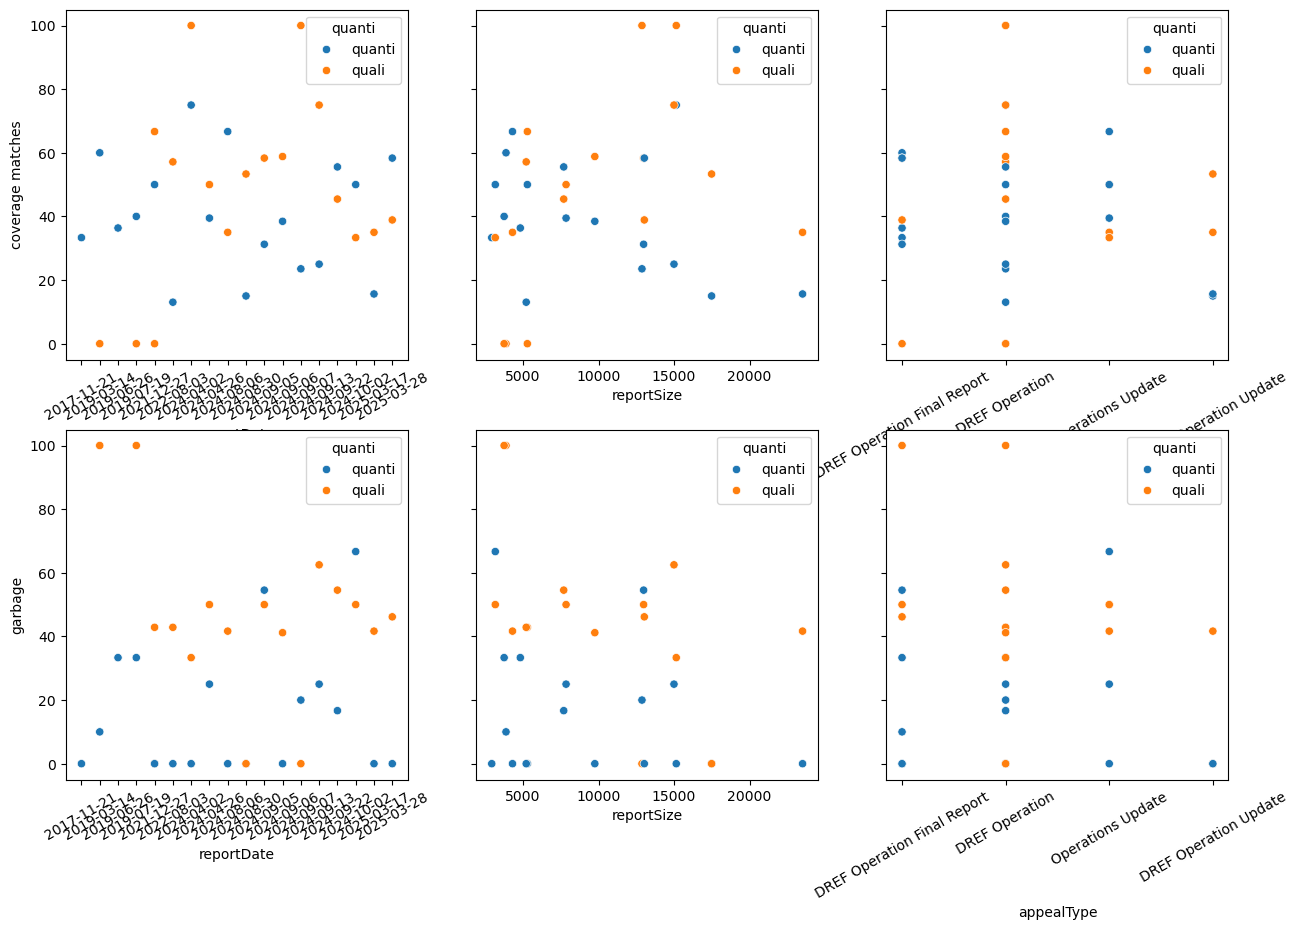

In [ ]:
#inspect sensitivity to other variables e.g. date report type, lentgth
external_vars = ["reportDate", "reportSize", "appealType"]
fig, axes = plt.subplots(2, len(external_vars), figsize=(15, 10), sharey=True, sharex=False)
coverage_df_match_appeal = coverage_df_match_appeal.sort_values("reportDate")
for i, var in enumerate(external_vars):
    sns.scatterplot(coverage_df_match_appeal, x=var, y="coverage matches", hue="quanti", ax=axes[0, i])
    sns.scatterplot(coverage_df_match_appeal, x=var, y="garbage", hue="quanti", ax=axes[1, i])
    if var in ["reportDate", "appealType"]:
        axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_external_vars_valerr_th-{value_error_th}_sim_th-{sim_th}_{filename_match}.png", bbox_inches="tight", dpi=300)

In [ ]:
#inspect sensitivity to thresholds

value_error_ths = np.arange(0.01, 0.3, 0.01)
sim_ths = np.arange(0.2, 1, 0.1)
vth_scores = []
for vth in value_error_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=vth, sim_th=0.6)
    make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None)
    vth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])

sth_scores = []
for sth in sim_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=0.1, sim_th=sth)
    sth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])


Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage m

<Axes: >

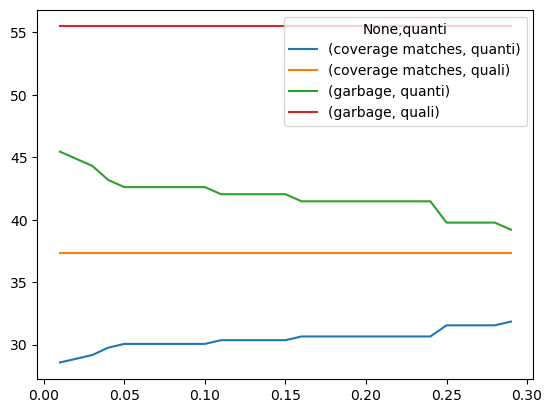

In [ ]:
sensi_vth_df = pd.concat(vth_scores, keys=value_error_ths).unstack()
sensi_vth_df.plot()

<Axes: >

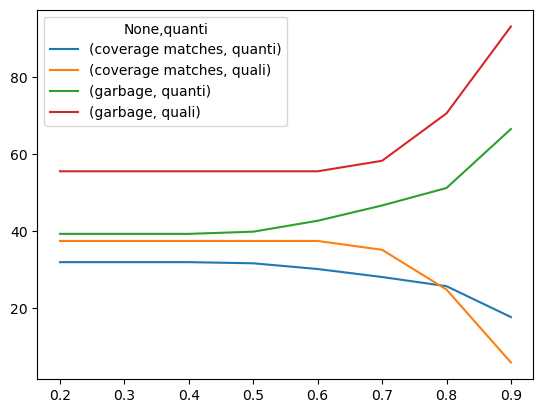

In [ ]:
sensi_sth_df = pd.concat(sth_scores, keys=sim_ths).unstack()
sensi_sth_df.plot()

In [ ]:
## Compare coverage by categories between labelled and extracted for all impacts

keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
extracted_lab_name = f"merged_subtypes_post_processed_labelled_reports_fixed_impact_desc_{key}_v271025"
extracted_all_name = f"merged_subtypes_post_processed_all_appeals_unique_1-333_{key}_v281025"

extracted_lab = pd.read_csv(DATA_OUT_PROC / (extracted_lab_name+".csv"))
extracted_df_long = pd.read_csv(DATA_OUT_PROC / (extracted_all_name+".csv"))


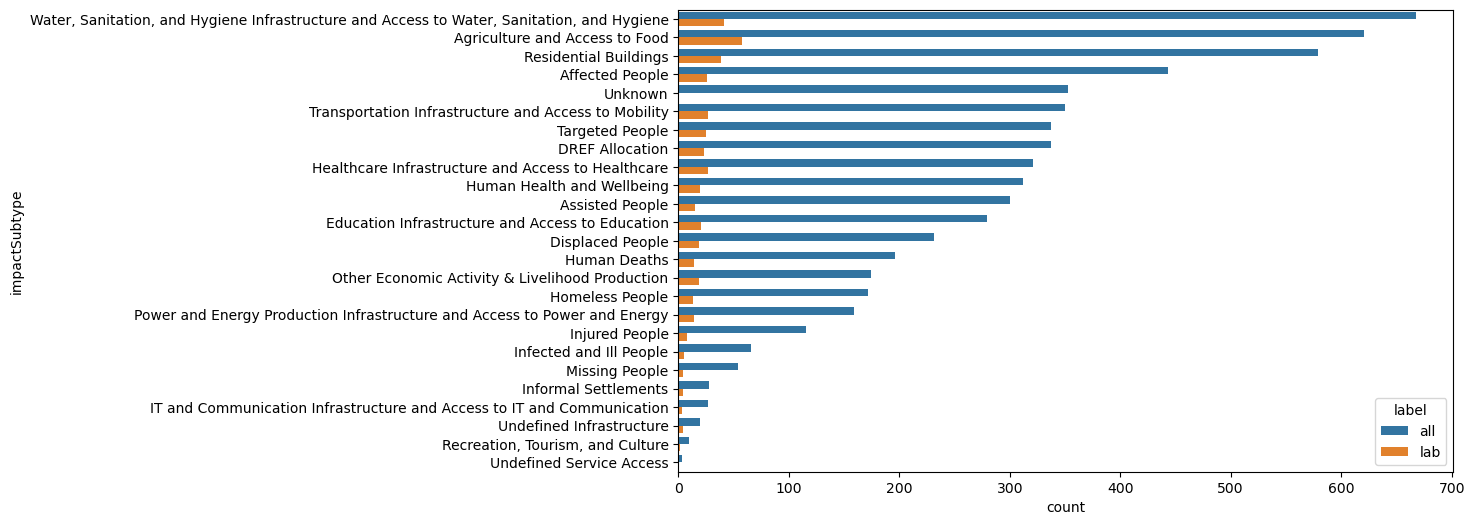

In [ ]:
#merge dfs
extracted_lab["label"] ="lab"
extracted_df_long["label"] = "all"
extracted_df_all = pd.concat([extracted_lab, extracted_df_long])
plot_df = extracted_df_all.value_counts(["impactSubtype", "label"]).reset_index()
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.barplot(data=plot_df, x="count", y="impactSubtype", hue="label", axes=ax)
fig.savefig(DATA_FIGURE / f"impactSubtype_distr_lab_vs_333_{extracted_lab_name}.png", bbox_inches="tight", dpi=300)
